In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import joblib

In [39]:
import os
data_path = os.path.join(os.path.dirname(os.getcwd()), 'Data', 'creditcard.csv')
df = pd.read_csv(data_path)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [41]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

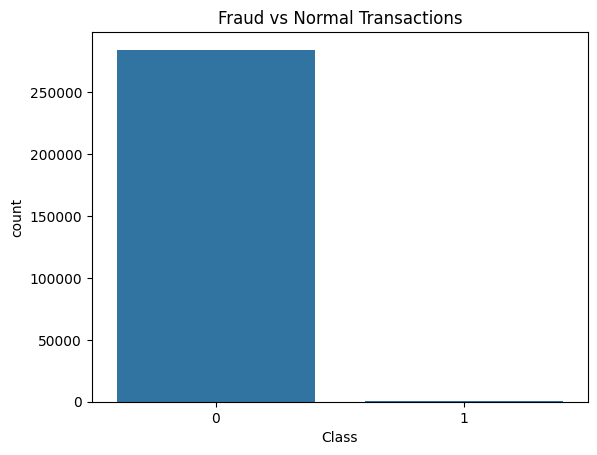

In [42]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [43]:
X = df.drop("Class", axis=1)
y=df["Class"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (227845, 30)
Test Shape: (56962, 30)


In [45]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [47]:
# 1. Define the model with constraints
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# 2. TRAIN IT (This fits the weights to the data)
model.fit(X_train_smote, y_train_smote)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [48]:
y_pred = model.predict(X_test)

In [49]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9995259997893332


In [50]:
y_prob = model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

In [51]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56854    10]
 [   17    81]]


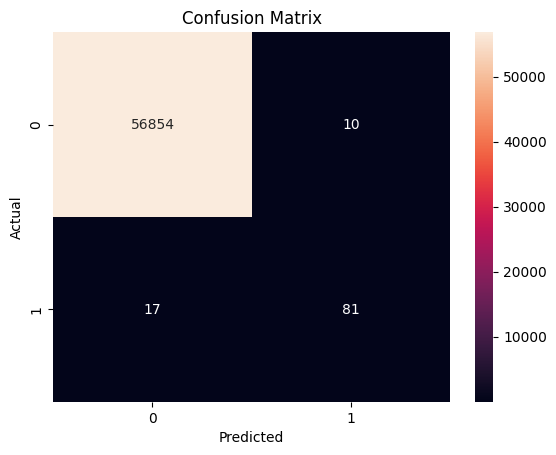

In [52]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [54]:
# =========================
# TEST MULTIPLE FRAUD SAMPLES
# =========================

fraud_df = df[df["Class"] == 1]

print("\nTesting Fraud Samples:\n")

for i in range(10):

    sample = fraud_df.drop(
        "Class",
        axis=1
    ).iloc[i]

    sample_array = sample.values.reshape(1, -1)

    sample_scaled = scaler.transform(
        sample_array
    )

    probability = model.predict_proba(
        sample_scaled
    )[0][1]

    print(
        f"Fraud Sample {i+1}: "
        f"{probability:.2%}"
    )


Testing Fraud Samples:

Fraud Sample 1: 57.50%
Fraud Sample 2: 3.50%
Fraud Sample 3: 98.50%
Fraud Sample 4: 82.50%
Fraud Sample 5: 97.50%
Fraud Sample 6: 100.00%


e:\Machine Learning\credit-card-fraud-detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
e:\Machine Learning\credit-card-fraud-detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
e:\Machine Learning\credit-card-fraud-detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
e:\Machine Learning\credit-card-fraud-detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
e:\Machine Learning\credit-card-fraud-detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning

Fraud Sample 7: 100.00%
Fraud Sample 8: 100.00%
Fraud Sample 9: 100.00%
Fraud Sample 10: 100.00%


e:\Machine Learning\credit-card-fraud-detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
e:\Machine Learning\credit-card-fraud-detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
e:\Machine Learning\credit-card-fraud-detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [55]:
models_dir = os.path.join(os.path.dirname(os.getcwd()), 'models')
joblib.dump(
    model,
    os.path.join(models_dir, 'fraud_model.pkl')
)

joblib.dump(
    scaler,
    os.path.join(models_dir, 'scaler.pkl')
)

print("Model overwritten successfully")

Model overwritten successfully


In [56]:
# =========================
# GET REAL FRAUD SAMPLES
# =========================

# Filter only fraud transactions
fraud_df = df[df["Class"] == 1]

# Remove target column
fraud_features = fraud_df.drop(
    "Class",
    axis=1
)

# Show 5 real fraud samples
for i in range(5):

    values = fraud_features.iloc[i].values

    formatted = ",".join(
        map(str, values)
    )

    print(f"\nFraud Sample {i+1}:\n")

    print(formatted)


Fraud Sample 1:

406.0,-2.3122265423263,1.95199201064158,-1.60985073229769,3.9979055875468,-0.522187864667764,-1.42654531920595,-2.53738730624579,1.39165724829804,-2.77008927719433,-2.77227214465915,3.20203320709635,-2.89990738849473,-0.595221881324605,-4.28925378244217,0.389724120274487,-1.14074717980657,-2.83005567450437,-0.0168224681808257,0.416955705037907,0.126910559061474,0.517232370861764,-0.0350493686052974,-0.465211076182388,0.320198198514526,0.0445191674731724,0.177839798284401,0.261145002567677,-0.143275874698919,0.0

Fraud Sample 2:

472.0,-3.0435406239976,-3.15730712090228,1.08846277997285,2.2886436183814,1.35980512966107,-1.06482252298131,0.325574266158614,-0.0677936531906277,-0.270952836226548,-0.838586564582682,-0.414575448285725,-0.503140859566824,0.676501544635863,-1.69202893305906,2.00063483909015,0.666779695901966,0.599717413841732,1.72532100745514,0.283344830149495,2.10233879259444,0.661695924845707,0.435477208966341,1.37596574254306,-0.293803152734021,0.279798031